# [9660] Homework 2 - Logistic Regression
Data file: https://raw.githubusercontent.com/vjavaly/Baruch-CIS-9660/main/data/mushrooms_1_30k.csv

## Homework Submission Rules (for all homework assignments)
* Homework is due by 6:30 PM on the due date
  * No late submission will be accepted
* Verify that you are submitting the correct homework file
* Homework file naming convention
  * LastName_FirstName_HwX.ipynb  [Replace X with the homework #]
    * 1 point deducted for submitting homework not complying with naming convention
* Before submission, execute "Kernel -> Restart Kernel and Run All Cells"
  * 1 point deducted for not submitting a cleanly executed notebook

## Homework 2 Requirements
* Load data into dataframe
* Examine data
* Prepare data for model training
  * Use SimpleImputer to replace missing values
  * Perform one-hot (dummy) encoding on categorical variable
  * Perform label encoding on target variable
* Train baseline Logistic Regression model
  * If you get errors, change appropriate hyperparameters to eliminate errors
  * Calculate and display model accuracy
  * Display confusion matrix
* Re-train Logistic Regression model to exceed accuracy of baseline model
  * Change hyperparameters accordingly to achieve this accuracy level
    * If you used hyperparameter random_state in your initial model training, do NOT change this value during model retrainings
    * Do NOT re-split training and test sets during model retrainings
  * Calculate and display accuracy of re-trained model
  * Display confusion matrix of re-trained model

### Submitted by Yashasvi Bhati (emplid: 24559155)

In [ ]:
from datetime import datetime
print(f'Run time: {datetime.now().strftime("%D %T")}')

Run time: 10/24/24 21:05:08


### Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

### Load data

#### Mushrooms poisonous / edible dataset
Columns
* class  : target variable : string (poisonous, edible)
* cap-diameter : float (cm)
* stem-height : float (cm)
* stem-width : float (cm)
* season : string (spring, summer, autumn, winter)
* cap-shape : binary : one-hot encoded features for cap-shape
  * cap-shape_convex
  * cap-shape_flat
  * cap-shape_sunken
* cap-color : binary : one-hot encoded features for cap-color
  * cap-color_brown
  * cap-color_orange
  * cap-color_red
  * cap-color_white
  * cap-color_yellow
* habitat : binary : one-hot encoded features for habitat
  * habitat_grasses
  * habitat_heaths
  * habitat_leaves
  * habitat_meadows
  * habitat_woods
* mushroom-id : unique identifier : integer

In [ ]:
# Read data from file (mushrooms_1_30k.csv) into dataframe
#  NOTES:
#   Field separator is ';'
#   Use mushroom-id as the index column

mush = pd.read_csv('https://raw.githubusercontent.com/vjavaly/Baruch-CIS-9660/main/data/mushrooms_1_30k.csv', sep= ';')
mush.set_index('mushroom-id', inplace=True)

In [ ]:
mush

,class,cap-diameter,stem-height,stem-width,season,cap-shape_convex,cap-shape_flat,cap-shape_sunken,cap-color_brown,cap-color_orange,cap-color_red,cap-color_white,cap-color_yellow,habitat_grasses,habitat_heaths,habitat_leaves,habitat_meadows,habitat_woods
mushroom-id,,,,,,,,,,,,,,,,,,
6899,poisonous,15.26,16.95,17.09,winter,1,0,0,0,1,0,0,0,0,0,0,0,1
9860,poisonous,16.60,17.99,18.19,summer,1,0,0,0,1,0,0,0,0,0,0,0,1
2436,poisonous,14.07,17.80,17.74,winter,1,0,0,0,1,0,0,0,0,0,0,0,1
9247,poisonous,14.17,15.77,15.98,winter,0,1,0,0,0,1,0,0,0,0,0,0,1
23440,poisonous,14.64,16.53,17.20,NaN,1,0,0,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7058,edible,11.50,6.74,21.56,autumn,1,0,0,1,0,0,0,0,0,0,0,0,1
28933,edible,10.06,9.44,23.81,summer,1,0,0,1,0,0,0,0,0,0,0,0,1
26838,edible,10.74,8.85,23.49,autumn,1,0,0,1,0,0,0,0,0,0,0,0,1


### Examine data

In [ ]:
# Review dataframe shape
mush.shape

(30000, 18)

In [ ]:
# Display first few rows of dataframe
mush.head(5)

,class,cap-diameter,stem-height,stem-width,season,cap-shape_convex,cap-shape_flat,cap-shape_sunken,cap-color_brown,cap-color_orange,cap-color_red,cap-color_white,cap-color_yellow,habitat_grasses,habitat_heaths,habitat_leaves,habitat_meadows,habitat_woods
mushroom-id,,,,,,,,,,,,,,,,,,
6899,poisonous,15.26,16.95,17.09,winter,1,0,0,0,1,0,0,0,0,0,0,0,1
9860,poisonous,16.60,17.99,18.19,summer,1,0,0,0,1,0,0,0,0,0,0,0,1
2436,poisonous,14.07,17.80,17.74,winter,1,0,0,0,1,0,0,0,0,0,0,0,1
9247,poisonous,14.17,15.77,15.98,winter,0,1,0,0,0,1,0,0,0,0,0,0,1
23440,poisonous,14.64,16.53,17.20,NaN,1,0,0,0,1,0,0,0,0,0,0,0,1


In [ ]:
# Display distribution counts for target variable 'class'
mush['class'].value_counts()

,count
class,
poisonous,16404
edible,13596


### Prepare data

#### Check for missing values

In [ ]:
mush.isna().sum()

,0
class,0
cap-diameter,195
stem-height,0
stem-width,0
season,329
cap-shape_convex,0
cap-shape_flat,0
cap-shape_sunken,0
cap-color_brown,0
cap-color_orange,0


#### Use the SimpleImputer to replace missing values

In [ ]:
# lets check dtypes for columns with missing values to work on the
mush.dtypes

,0
class,object
cap-diameter,float64
stem-height,float64
stem-width,float64
season,object
cap-shape_convex,int64
cap-shape_flat,int64
cap-shape_sunken,int64
cap-color_brown,int64
cap-color_orange,int64


In [ ]:
# cap-diameter is a numeric column and season is a category column, thus we will handle both the columns spearately
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
cols_to_impute_1 = ['cap-diameter']
mush[cols_to_impute_1] = imp_mean.fit_transform(mush[cols_to_impute_1])

imp_most_freq = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
cols_to_impute_2 = ['season']
mush[cols_to_impute_2] = imp_most_freq.fit_transform(mush[cols_to_impute_2])

#### Check for missing values again

In [ ]:
mush.isna().sum()

,0
class,0
cap-diameter,0
stem-height,0
stem-width,0
season,0
cap-shape_convex,0
cap-shape_flat,0
cap-shape_sunken,0
cap-color_brown,0
cap-color_orange,0


### Review updated dataframe

In [ ]:
mush.head(5)

,class,cap-diameter,stem-height,stem-width,season,cap-shape_convex,cap-shape_flat,cap-shape_sunken,cap-color_brown,cap-color_orange,cap-color_red,cap-color_white,cap-color_yellow,habitat_grasses,habitat_heaths,habitat_leaves,habitat_meadows,habitat_woods
mushroom-id,,,,,,,,,,,,,,,,,,
6899,poisonous,15.26,16.95,17.09,winter,1,0,0,0,1,0,0,0,0,0,0,0,1
9860,poisonous,16.60,17.99,18.19,summer,1,0,0,0,1,0,0,0,0,0,0,0,1
2436,poisonous,14.07,17.80,17.74,winter,1,0,0,0,1,0,0,0,0,0,0,0,1
9247,poisonous,14.17,15.77,15.98,winter,0,1,0,0,0,1,0,0,0,0,0,0,1
23440,poisonous,14.64,16.53,17.20,autumn,1,0,0,0,1,0,0,0,0,0,0,0,1


#### One-hot (dummy) encode categorical variable 'season'

In [ ]:
# checking for unique values
mush['season'].unique()

array(['winter', 'summer', 'autumn', 'spring'], dtype=object)

In [ ]:
# performing dummy encoding
mush = pd.get_dummies(mush, columns=['season'], dtype=int)
mush.head()

,class,cap-diameter,stem-height,stem-width,cap-shape_convex,cap-shape_flat,cap-shape_sunken,cap-color_brown,cap-color_orange,cap-color_red,...,cap-color_yellow,habitat_grasses,habitat_heaths,habitat_leaves,habitat_meadows,habitat_woods,season_autumn,season_spring,season_summer,season_winter
mushroom-id,,,,,,,,,,,,,,,,,,,,,
6899,poisonous,15.26,16.95,17.09,1,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,1
9860,poisonous,16.60,17.99,18.19,1,0,0,0,1,0,...,0,0,0,0,0,1,0,0,1,0
2436,poisonous,14.07,17.80,17.74,1,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,1
9247,poisonous,14.17,15.77,15.98,0,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,1
23440,poisonous,14.64,16.53,17.20,1,0,0,0,1,0,...,0,0,0,0,0,1,1,0,0,0


#### Label encode target variable 'class'

In [ ]:
le = LabelEncoder()
mush['class']= le.fit_transform(mush['class'])
mush.head()

,class,cap-diameter,stem-height,stem-width,cap-shape_convex,cap-shape_flat,cap-shape_sunken,cap-color_brown,cap-color_orange,cap-color_red,...,cap-color_yellow,habitat_grasses,habitat_heaths,habitat_leaves,habitat_meadows,habitat_woods,season_autumn,season_spring,season_summer,season_winter
mushroom-id,,,,,,,,,,,,,,,,,,,,,
6899,1,15.26,16.95,17.09,1,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,1
9860,1,16.60,17.99,18.19,1,0,0,0,1,0,...,0,0,0,0,0,1,0,0,1,0
2436,1,14.07,17.80,17.74,1,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,1
9247,1,14.17,15.77,15.98,0,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,1
23440,1,14.64,16.53,17.20,1,0,0,0,1,0,...,0,0,0,0,0,1,1,0,0,0


### Display first few rows of final updated dataframe before model training

In [ ]:
mush.head(10)

,class,cap-diameter,stem-height,stem-width,cap-shape_convex,cap-shape_flat,cap-shape_sunken,cap-color_brown,cap-color_orange,cap-color_red,...,cap-color_yellow,habitat_grasses,habitat_heaths,habitat_leaves,habitat_meadows,habitat_woods,season_autumn,season_spring,season_summer,season_winter
mushroom-id,,,,,,,,,,,,,,,,,,,,,
6899,1,15.26,16.95,17.09,1,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,1
9860,1,16.60,17.99,18.19,1,0,0,0,1,0,...,0,0,0,0,0,1,0,0,1,0
2436,1,14.07,17.80,17.74,1,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,1
9247,1,14.17,15.77,15.98,0,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,1
23440,1,14.64,16.53,17.20,1,0,0,0,1,0,...,0,0,0,0,0,1,1,0,0,0
21161,1,15.34,17.84,18.79,1,0,0,0,1,0,...,0,0,0,0,0,1,0,0,1,0
15255,1,14.85,17.71,16.89,0,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,1
4057,1,14.86,17.03,17.44,1,0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0
31596,1,12.85,17.27,18.69,0,1,0,0,1,0,...,0,0,0,0,0,1,1,0,0,0


In [ ]:
# since all the classes in the 'class' displays the same values, lets do a sample() to cross check
mush.sample(10)

,class,cap-diameter,stem-height,stem-width,cap-shape_convex,cap-shape_flat,cap-shape_sunken,cap-color_brown,cap-color_orange,cap-color_red,...,cap-color_yellow,habitat_grasses,habitat_heaths,habitat_leaves,habitat_meadows,habitat_woods,season_autumn,season_spring,season_summer,season_winter
mushroom-id,,,,,,,,,,,,,,,,,,,,,
5124,1,7.78,5.23,8.20,0,1,0,0,0,0,...,1,0,0,0,0,1,1,0,0,0
8118,0,3.90,5.46,6.73,1,0,0,1,0,0,...,0,0,0,0,0,1,1,0,0,0
34698,1,7.44,6.49,9.94,1,0,0,0,0,1,...,0,0,0,0,0,1,1,0,0,0
33730,1,0.81,4.73,1.09,0,1,0,0,1,0,...,0,1,0,0,0,0,1,0,0,0
36657,1,8.96,12.63,16.00,1,0,0,1,0,0,...,0,0,1,0,0,0,1,0,0,0
26593,1,3.48,4.91,6.40,1,0,0,1,0,0,...,0,0,0,0,0,1,1,0,0,0
25205,1,3.48,7.21,3.63,0,1,0,1,0,0,...,0,0,0,0,0,1,1,0,0,0
9533,1,4.00,6.25,6.89,1,0,0,0,0,0,...,1,1,0,0,0,0,0,0,1,0
9694,1,6.22,5.00,15.67,1,0,0,0,0,0,...,1,0,0,0,0,1,1,0,0,0


### Separate independent and dependent variables
* Independent variables: All remaining variables except 'class'
* Dependent variable: 'class'

In [ ]:
X = mush.drop('class', axis=1)  # Independent variables
y = mush['class']  # Dependent variable

### Split data into training and test sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,stratify=y,
                                                    test_size=0.3, random_state=42)
# random_state is used for teaching purposes only

### Train Logistic Regression model

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

### If the above results in error, review the error message, look up the documentation for LogisticRegression, change the appropriate model hyperparameter and re-train the model
* Repeat until there is no error

In [ ]:
model = LogisticRegression(max_iter = 300)
model.fit(X_train, y_train)

LogisticRegression(max_iter=300)

### Test model

In [ ]:
# Generate predictions against the test set
predictions = model.predict(X_test)

In [ ]:
print(predictions)

[0 1 0 ... 1 0 1]


### Model evaluation

In [ ]:
# printing model accuracy
accuracy = model.score(X_test, y_test)
print("accuracy = ", round((accuracy * 100), 2), "%")

accuracy =  65.66 %


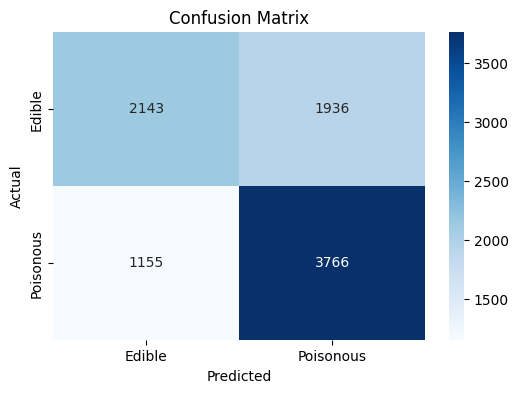

In [ ]:
# Display confusion matrix with class labels
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Edible', 'Poisonous'], yticklabels=['Edible', 'Poisonous'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Re-train logistic regression model with different hyperparameters
Goal: Improve model performance accuracy to exceed that of baseline model

In [ ]:
#  to use hyperparameters better, lets start by understanding the use and effect of each of it
model.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 300,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [ ]:
# Re-train model with different hyperparameters
model = LogisticRegression(max_iter = 900, C = 0.01)
model.fit(X_train, y_train)

LogisticRegression(C=0.01, max_iter=900)

### Test updated model

In [ ]:
# Generate predictions against the test set
new_predictions = model.predict(X_test)

In [ ]:
print(new_predictions)

[0 1 0 ... 1 0 1]


### Evaluate updated model

In [ ]:
# Print updated model accuracy
accuracy = model.score(X_test, y_test)
print(" tuned_accuracy = ", round((accuracy * 100), 2), "%")

 tuned_accuracy =  66.33 %


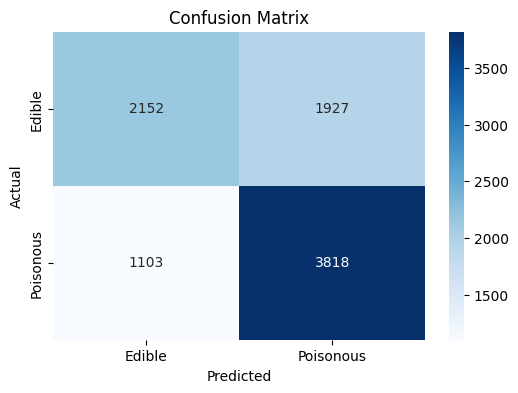

In [ ]:
# Display updated confusion matrix with class labels
cm_new = confusion_matrix(y_test, new_predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues', xticklabels=['Edible', 'Poisonous'], yticklabels=['Edible', 'Poisonous'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()